In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", None)

project_root = Path.cwd().resolve()
while not (project_root / "data").is_dir() and project_root != project_root.parent:
    project_root = project_root.parent

data_path = project_root / "data" / "processed" / "ev_predictive_maintenance_cleaned.csv"
if not data_path.exists():
    raise FileNotFoundError(f"Cleaned dataset not found at {data_path}. Run the preprocessing script first.")


## 1. Load and inspect the dataset

In [2]:
df = pd.read_csv(data_path, parse_dates=["timestamp"])

print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
display(df.head())
display(df.dtypes.to_frame(name="data_type"))

Dataset shape: 175,393 rows x 30 columns


,timestamp,soc,soh,battery_voltage,battery_current,battery_temperature,charge_cycles,motor_temperature,motor_vibration,motor_torque,motor_rpm,power_consumption,brake_pad_wear,brake_pressure,reg_brake_efficiency,tire_pressure,tire_temperature,suspension_load,ambient_temperature,ambient_humidity,load_weight,driving_speed,distance_traveled,idle_time,route_roughness,rul,failure_probability,maintenance_type,ttf,component_health_score
0,2020-01-01 00:00:00,0.826099,0.941338,210.163881,-22.753095,27.149201,149.190930,48.496049,0.369095,113.435589,1996.008632,28.491339,0.237134,46.246011,0.810858,24.318716,26.699988,187.132154,13.213039,94.621365,741.754518,103.421162,66.232383,0.520922,0.225970,260.503381,0,1,111.116697,0.852745
1,2020-01-01 00:15:00,0.064728,0.916059,364.000102,-27.701120,53.655101,171.702388,57.829492,1.449195,105.587160,1798.361835,25.450963,0.126469,35.790875,0.889325,24.266465,27.214893,101.420835,-6.713220,41.033266,769.134035,46.041935,3.146238,0.844005,0.204350,212.813954,0,2,179.229425,0.827616
2,2020-01-01 00:30:00,0.873643,0.908020,388.855089,-36.646406,29.559090,191.617645,46.518363,1.859045,119.610302,1881.417071,22.618821,0.199936,30.896217,0.913198,33.387677,33.147433,175.720864,24.078900,34.406233,917.262931,59.588422,79.909148,0.992405,0.175125,273.394511,0,1,171.852663,0.876887
3,2020-01-01 00:45:00,0.853009,0.916476,370.570602,-37.609429,29.690283,111.881817,54.163681,0.381500,182.535625,1593.549698,20.838012,0.138880,43.541937,0.899215,32.261760,32.924688,129.309498,11.949569,44.478083,600.598736,44.222285,0.774000,0.007615,0.213264,229.508442,0,0,165.221328,0.816290
4,2020-01-01 01:00:00,0.947540,0.913206,390.011904,-14.275808,28.864338,163.774377,42.075978,0.433927,173.298044,1585.970891,23.663755,0.249649,48.761583,0.471733,33.083867,26.806491,165.171360,18.953288,42.783036,613.153029,41.374684,2.872124,0.771938,0.770257,257.302631,1,0,176.890659,0.744260


,data_type
timestamp,datetime64[us]
soc,float64
soh,float64
battery_voltage,float64
battery_current,float64
battery_temperature,float64
charge_cycles,float64
motor_temperature,float64
motor_vibration,float64
motor_torque,float64


## 2. Data-quality checks

Confirm that the cleaned data has no missing values or duplicate records.

In [3]:
quality_summary = pd.DataFrame({
    "missing_values": df.isna().sum(),
    "unique_values": df.nunique(),
    "data_type": df.dtypes.astype(str),
})

print(f"Exact duplicate rows: {df.duplicated().sum():,}")
print(f"Timestamp range: {df['timestamp'].min()} to {df['timestamp'].max()}")
display(quality_summary)

Exact duplicate rows: 0
Timestamp range: 2020-01-01 00:00:00 to 2025-01-01 00:00:00


,missing_values,unique_values,data_type
timestamp,0,175393,datetime64[us]
soc,0,175393,float64
soh,0,175393,float64
battery_voltage,0,175393,float64
battery_current,0,175393,float64
battery_temperature,0,175393,float64
charge_cycles,0,175393,float64
motor_temperature,0,175393,float64
motor_vibration,0,175393,float64
motor_torque,0,175393,float64


## 3. Numerical summary

Review the range and spread of the EV sensor and usage variables.

In [4]:
numeric_columns = df.select_dtypes(include="number").columns.tolist()
display(df[numeric_columns].describe().T.round(3))

,count,mean,std,min,25%,50%,75%,max
soc,175393.0,0.780,0.292,0.000,0.824,0.882,0.941,1.000
soh,175393.0,0.882,0.165,0.400,0.912,0.941,0.971,1.000
battery_voltage,175393.0,352.713,55.247,200.001,355.990,370.587,385.263,399.999
battery_current,175393.0,-47.892,45.358,-199.994,-45.270,-33.518,-21.758,-10.000
battery_temperature,175393.0,33.399,8.655,25.000,27.948,30.888,33.826,59.998
charge_cycles,175393.0,217.685,164.507,100.001,129.489,158.901,188.313,699.997
motor_temperature,175393.0,56.027,15.447,40.000,45.873,51.757,57.678,100.000
motor_vibration,175393.0,0.524,0.434,0.200,0.289,0.376,0.465,2.000
motor_torque,175393.0,179.786,76.767,100.000,129.470,158.810,188.025,399.998
motor_rpm,175393.0,2235.504,1188.120,1500.006,1646.973,1793.947,1941.249,6000.000


## 4. Candidate targets

Choose one target before modelling. Maintenance type is suited to classification, while RUL, TTF, and component health score are regression targets.

In [5]:
candidate_targets = [
    "failure_probability", "maintenance_type", "rul", "ttf", "component_health_score"
]

display(df[candidate_targets].describe().T.round(3))
display(df["maintenance_type"].value_counts().sort_index().to_frame(name="record_count"))

,count,mean,std,min,25%,50%,75%,max
failure_probability,175393.0,0.099,0.298,0.0,0.000,0.000,0.000,1.000
maintenance_type,175393.0,0.498,0.866,0.0,0.000,0.000,1.000,3.000
rul,175393.0,216.366,84.594,0.0,211.700,241.127,270.517,300.000
ttf,175393.0,129.724,55.179,0.0,111.816,141.216,170.508,199.999
component_health_score,175393.0,0.744,0.265,0.0,0.735,0.823,0.912,1.000


,record_count
maintenance_type,
0,122958
1,26242
2,17402
3,8791


## 5. Sensor distributions

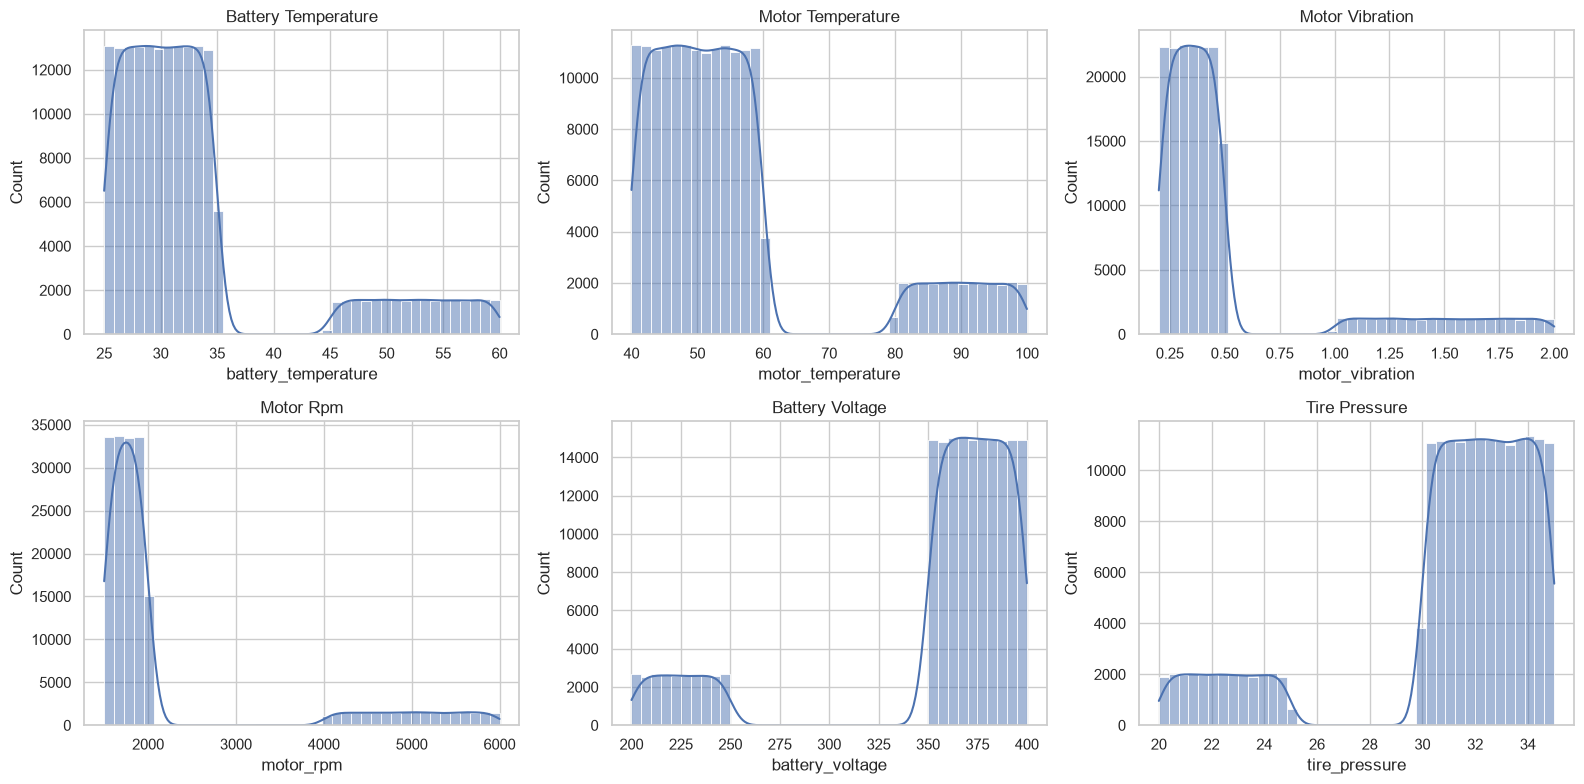

In [6]:
sensor_columns = [
    "battery_temperature", "motor_temperature", "motor_vibration",
    "motor_rpm", "battery_voltage", "tire_pressure"
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for axis, column in zip(axes.flat, sensor_columns):
    sns.histplot(df[column], bins=40, kde=True, ax=axis)
    axis.set_title(column.replace("_", " ").title())

plt.tight_layout()
plt.show()

## 6. Correlation with continuous targets

Correlation highlights linear relationships, but does not show causation.

,failure_probability,rul,ttf,component_health_score
soc,0.004,-0.000,0.001,-0.000
soh,-0.003,0.001,-0.001,-0.003
battery_voltage,-0.000,0.001,0.000,0.003
battery_current,-0.002,-0.001,0.001,0.002
battery_temperature,0.002,-0.003,-0.007,0.003
charge_cycles,-0.002,0.005,-0.001,0.005
motor_temperature,-0.000,-0.001,-0.006,0.003
motor_vibration,0.001,-0.002,0.001,-0.001
motor_torque,-0.001,-0.002,-0.002,-0.006
motor_rpm,0.001,-0.001,0.001,0.000


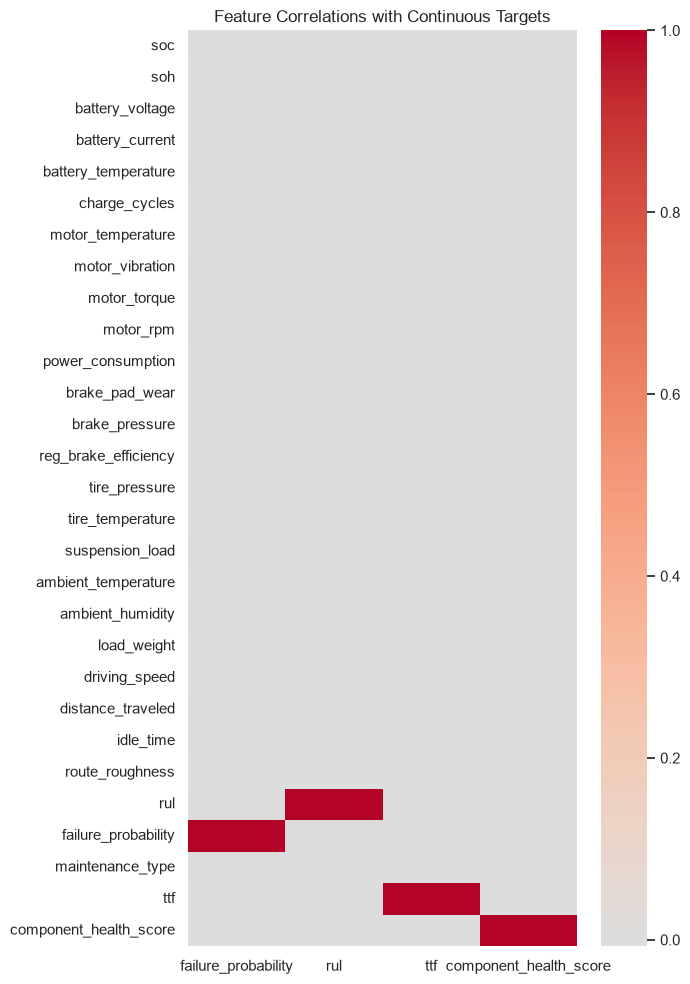

In [7]:
continuous_targets = ["failure_probability", "rul", "ttf", "component_health_score"]
correlations = df[numeric_columns].corr()[continuous_targets]
display(correlations.round(3))

plt.figure(figsize=(7, 10))
sns.heatmap(correlations, cmap="coolwarm", center=0, annot=False)
plt.title("Feature Correlations with Continuous Targets")
plt.tight_layout()
plt.show()

## 7. Sensor values by maintenance type

A sample is used to keep the box plots fast and readable.

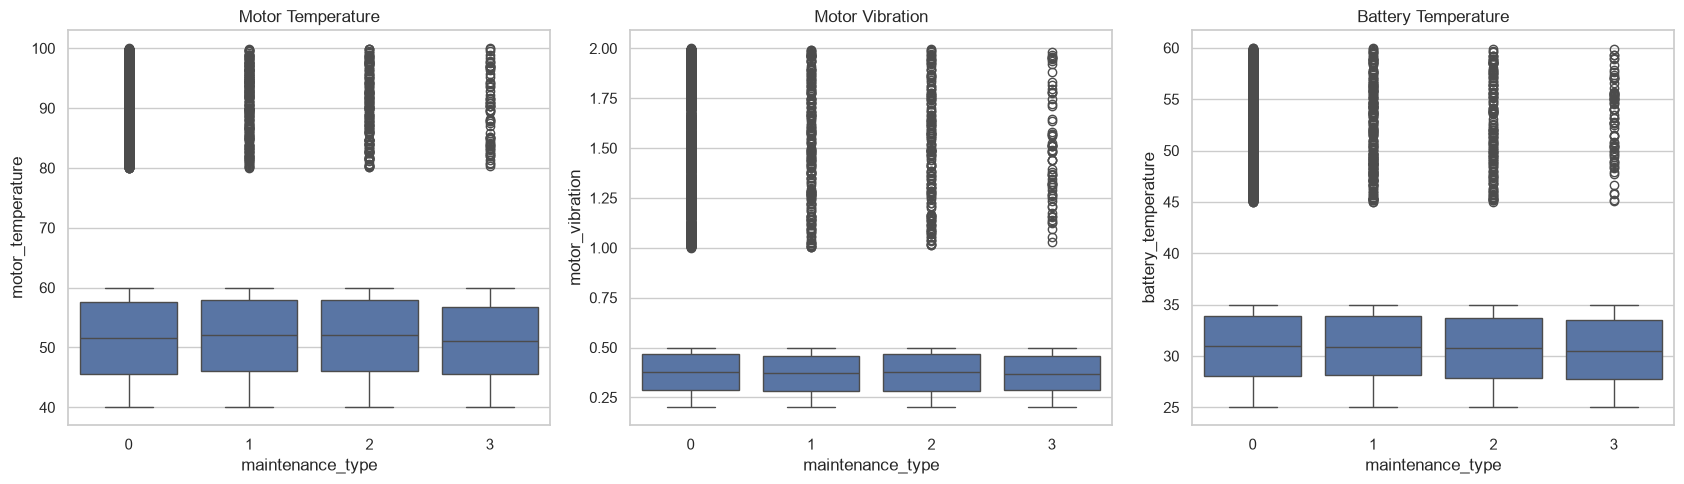

In [8]:
plot_sample = df.sample(n=min(10_000, len(df)), random_state=42)
comparison_columns = ["motor_temperature", "motor_vibration", "battery_temperature"]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for axis, column in zip(axes, comparison_columns):
    sns.boxplot(data=plot_sample, x="maintenance_type", y=column, ax=axis)
    axis.set_title(column.replace("_", " ").title())

plt.tight_layout()
plt.show()

## 8. Decision before modelling

- **Selected target:** `failure_probability`
- **Problem type:** Binary classification (`0` = no failure risk, `1` = failure risk)
- **Initial features:** Sensor, battery, driving, and environmental columns.
- **Excluded columns:** `timestamp`, `maintenance_type`, `rul`, `ttf`, and `component_health_score`. The target `failure_probability` is also excluded from the input features.
- **Reason for excluding:** These are timestamps or other outcome-related columns, so they could give the model an unfair hint.
- **Future extension:** After predicting failure risk, predict `maintenance_type` to recommend the kind of maintenance needed.
- **Next step:** Build feature-selection code, then train and evaluate a baseline binary classification model.